# Notebook 5: Results and Policy Implications

## Objective
Summarise the key findings from the exploratory analysis, clustering and early warning model, and discuss their implications from a macroprudential policy perspective.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean dataset
df = pd.read_csv("banking_indicators_clean.csv")
df['Period'] = pd.to_datetime(df['Period'])
df = df[df['CET1_ratio'] < 50].copy()

# Load cluster assignments from notebook 3
df_latest = df[df['Period'] == df['Period'].max()].copy()

# Summary table: latest CET1 ratio by country
summary = df_latest.groupby('Country').agg(
    n_banks=('Name', 'count'),
    avg_CET1=('CET1_ratio', 'mean'),
    min_CET1=('CET1_ratio', 'min'),
    banks_below_15=('CET1_ratio', lambda x: (x < 15).sum())
).round(2).sort_values('avg_CET1')

print(summary.to_string())

         n_banks  avg_CET1  min_CET1  banks_below_15
Country                                             
ES            10     14.14     12.25               8
SI             2     15.90     15.06               0
GR             4     16.13     14.19               1
PL             2     16.47     16.14               0
SE             5     17.05     14.52               1
PT             3     17.42     14.99               1
DK             3     17.43     16.26               0
AT             5     17.49     12.55               2
FI             2     17.94     15.11               0
HU             2     18.16     17.98               0
IE             5     18.39     15.28               0
EE             1     18.43     18.43               0
LI             2     18.46     18.43               0
IT            12     18.61     12.97               3
NO             3     18.62     18.33               0
MT             2     19.60     16.99               0
FR            11     19.62     12.46          

## 1. Country-level Vulnerability Overview (Q2 2025)

The table below summarises capital adequacy across 25 European countries
based on the latest available data (Q2 2025).

**Key findings:**

**Spain (ES) is the most capital-constrained country:**
With an average CET1 ratio of 14.1% and 8 out of 10 banks below 15%, Spain consistently emerges as the country with the tightest capital buffers.
While all banks remain above the regulatory minimum, the limited headroom above the 15% caution threshold warrants close monitoring.

**Greece (GR), Austria (AT) and Italy (IT) also warrant attention:**
These countries show a combination of below-average CET1 ratios and multiple banks in the caution zone (below 15%).

**Northern and smaller economies show stronger capitalisation:**
Lithuania (24.5%), Netherlands (24.0%) and Romania (21.3%) show the highest average CET1 ratios, reflecting more conservative capital management or less complex business models.

**France and Germany are broadly solid despite large bank presence:**
Both countries have banks in the caution zone, but their averages (19.6% and 20.0%) remain comfortable. The presence of large systemic banks with lower CET1 ratios explains 
the within-country dispersion.

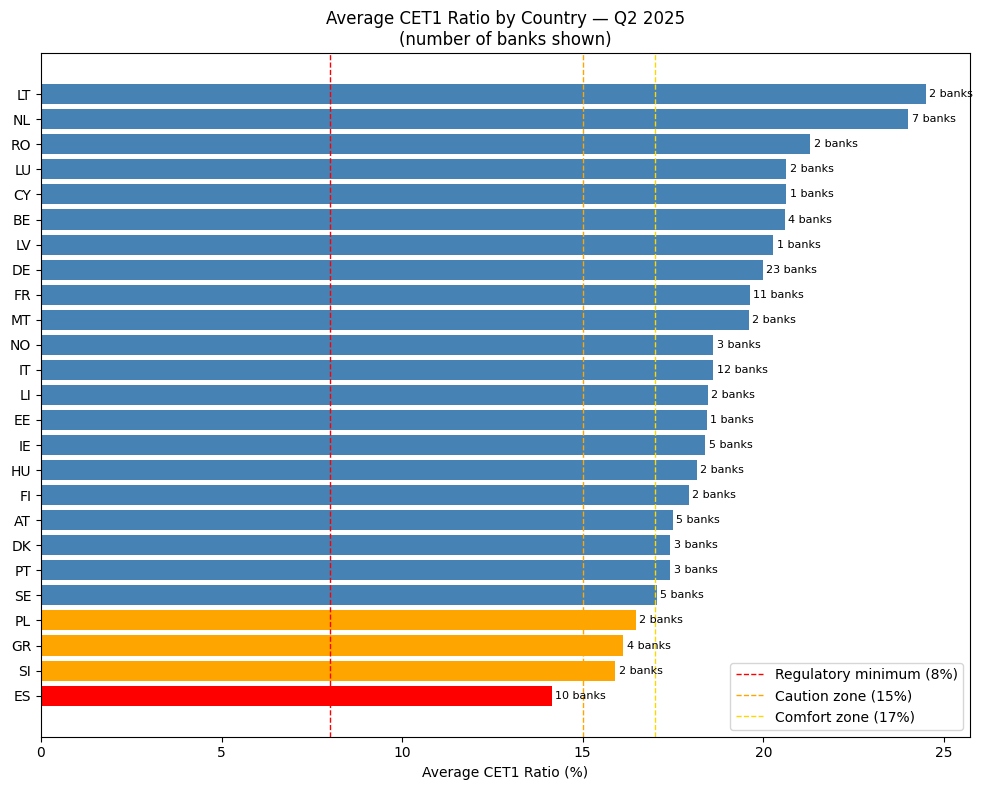

In [2]:
# Vulnerability heatmap by country
fig, ax = plt.subplots(figsize=(10, 8))

# Sort by average CET1
summary_sorted = summary.sort_values('avg_CET1')

# Color bars by vulnerability level
colors = ['red' if x < 15 else 'orange' if x < 17 else 'steelblue' 
          for x in summary_sorted['avg_CET1']]

bars = ax.barh(summary_sorted.index, summary_sorted['avg_CET1'], color=colors)
ax.axvline(x=8, color='red', linestyle='--', linewidth=1, label='Regulatory minimum (8%)')
ax.axvline(x=15, color='orange', linestyle='--', linewidth=1, label='Caution zone (15%)')
ax.axvline(x=17, color='gold', linestyle='--', linewidth=1, label='Comfort zone (17%)')

# Add number of banks as annotation
for i, (idx, row) in enumerate(summary_sorted.iterrows()):
    ax.text(row['avg_CET1'] + 0.1, i, 
            str(int(row['n_banks'])) + ' banks', 
            va='center', fontsize=8)

ax.set_title('Average CET1 Ratio by Country — Q2 2025\n(number of banks shown)')
ax.set_xlabel('Average CET1 Ratio (%)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_09_country_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Conclusions

This project developed an end-to-end Early Warning System for banking sector vulnerabilities in the euro area, using publicly available EBA supervisory data.

**Main findings:**

1. **The European banking sector is broadly resilient.** No bank in the sample falls below the 8% regulatory minimum. The average CET1 ratio across 119 institutions is 18.6%, well above minimum requirements.

2. **Spain is the most capital-constrained country.** With 8 out of 10 banks below the 15% caution threshold and an average CET1 of 14.1%, Spain consistently emerges as the most vulnerable banking system in the sample.

3. **Three structurally distinct bank clusters exist.** Standard institutions (92 banks), large systemic banks (8 banks) and high-capital specialised institutions (5 banks) have fundamentally different risk profiles and warrant differentiated supervisory approaches.

4. **The Early Warning Model achieves strong predictive performance.**
   Logistic Regression achieves AUC=0.98 on the test set, with 95% accuracy. The current CET1 ratio is by far the most important predictor of future capital adequacy.

5. **Large systemic banks warrant macroprudential attention.** Despite their apparent resilience at the system level, institutions like BNP Paribas, Santander and Deutsche Bank operate with relatively thin capital buffers and have significant cross-border spillover potential.

## 3. Limitations and Further Research

**Data limitations:**
- Only 4 quarters of data available — a longer time series would improve model robustness and allow capturing cyclical dynamics
- Key indicators such as NPL ratio, liquidity coverage ratio (LCR) and return on equity (ROE) are available in other EBA files but were not integrated

**Model limitations:**
- The high AUC is partly driven by CET1 autocorrelation — the model largely predicts that low-CET1 banks remain low-CET1
- No macroeconomic scenario analysis, a true stress test would incorporate adverse GDP, interest rate and unemployment shocks
- The binary classification threshold (15%) is arbitrary and could be calibrated against actual supervisory outcomes

**Extensions for future work:**
- Integrate NPL and profitability data from EBA credit risk templates
- Add macroeconomic variables from the ECB Data Portal (GDP growth, inflation, sovereign spreads)
- Extend to a multi-period panel model with fixed effects
- Apply SHAP values for bank-level explainability of risk scores